# Intel Image Classification — Simple CNN
**오늘 한 줄**: 70%에서 멈추는 건 모델이 게으른 게 아니라, 구조가 부족한 거다.

흐름: 데이터 확인 → Simple CNN 학습 → 약점 분석 → 튜닝으로 개선

> 데이터: [puneet6060/intel-image-classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

In [4]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    if 'seg_train' in dirs:
        print(f'BASE: {root}')
        break

In [5]:
# 한글폰트 필요하면
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess

# 폰트 설치
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

# 설치된 나눔 폰트 경로 직접 찾기
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print(f'폰트 적용: {prop.get_name()}')

폰트 적용: NanumGothic


In [9]:
import os

print(os.getcwd())
print(os.listdir('.'))

/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/숙제/cv
['Day1_baseline_CNN.ipynb']


## [1] 환경 준비

In [10]:
import os, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 시드 고정
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

# 경로 자동 탐색
BASE = '/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/data/intel-image-classification'


TRAIN_DIR = os.path.join(BASE, 'seg_train', 'seg_train')
TEST_DIR  = os.path.join(BASE, 'seg_test',  'seg_test')
print(f'train exists: {os.path.exists(TRAIN_DIR)}')
print(f'test  exists: {os.path.exists(TEST_DIR)}')

device: cuda
train exists: True
test  exists: True


## [2] EDA — 클래스 분포 + 이미지 직접 보기
**볼 것**: 어떤 클래스 쌍이 시각적으로 비슷한가? → 오늘 약점 후보

클래스별 이미지 수
  buildings   : 2191
  forest      : 2271
  glacier     : 2404
  mountain    : 2512
  sea         : 2274
  street      : 2382


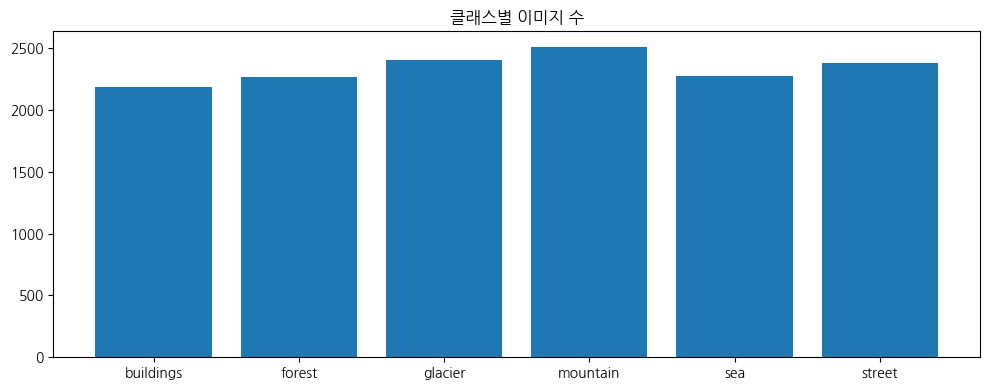

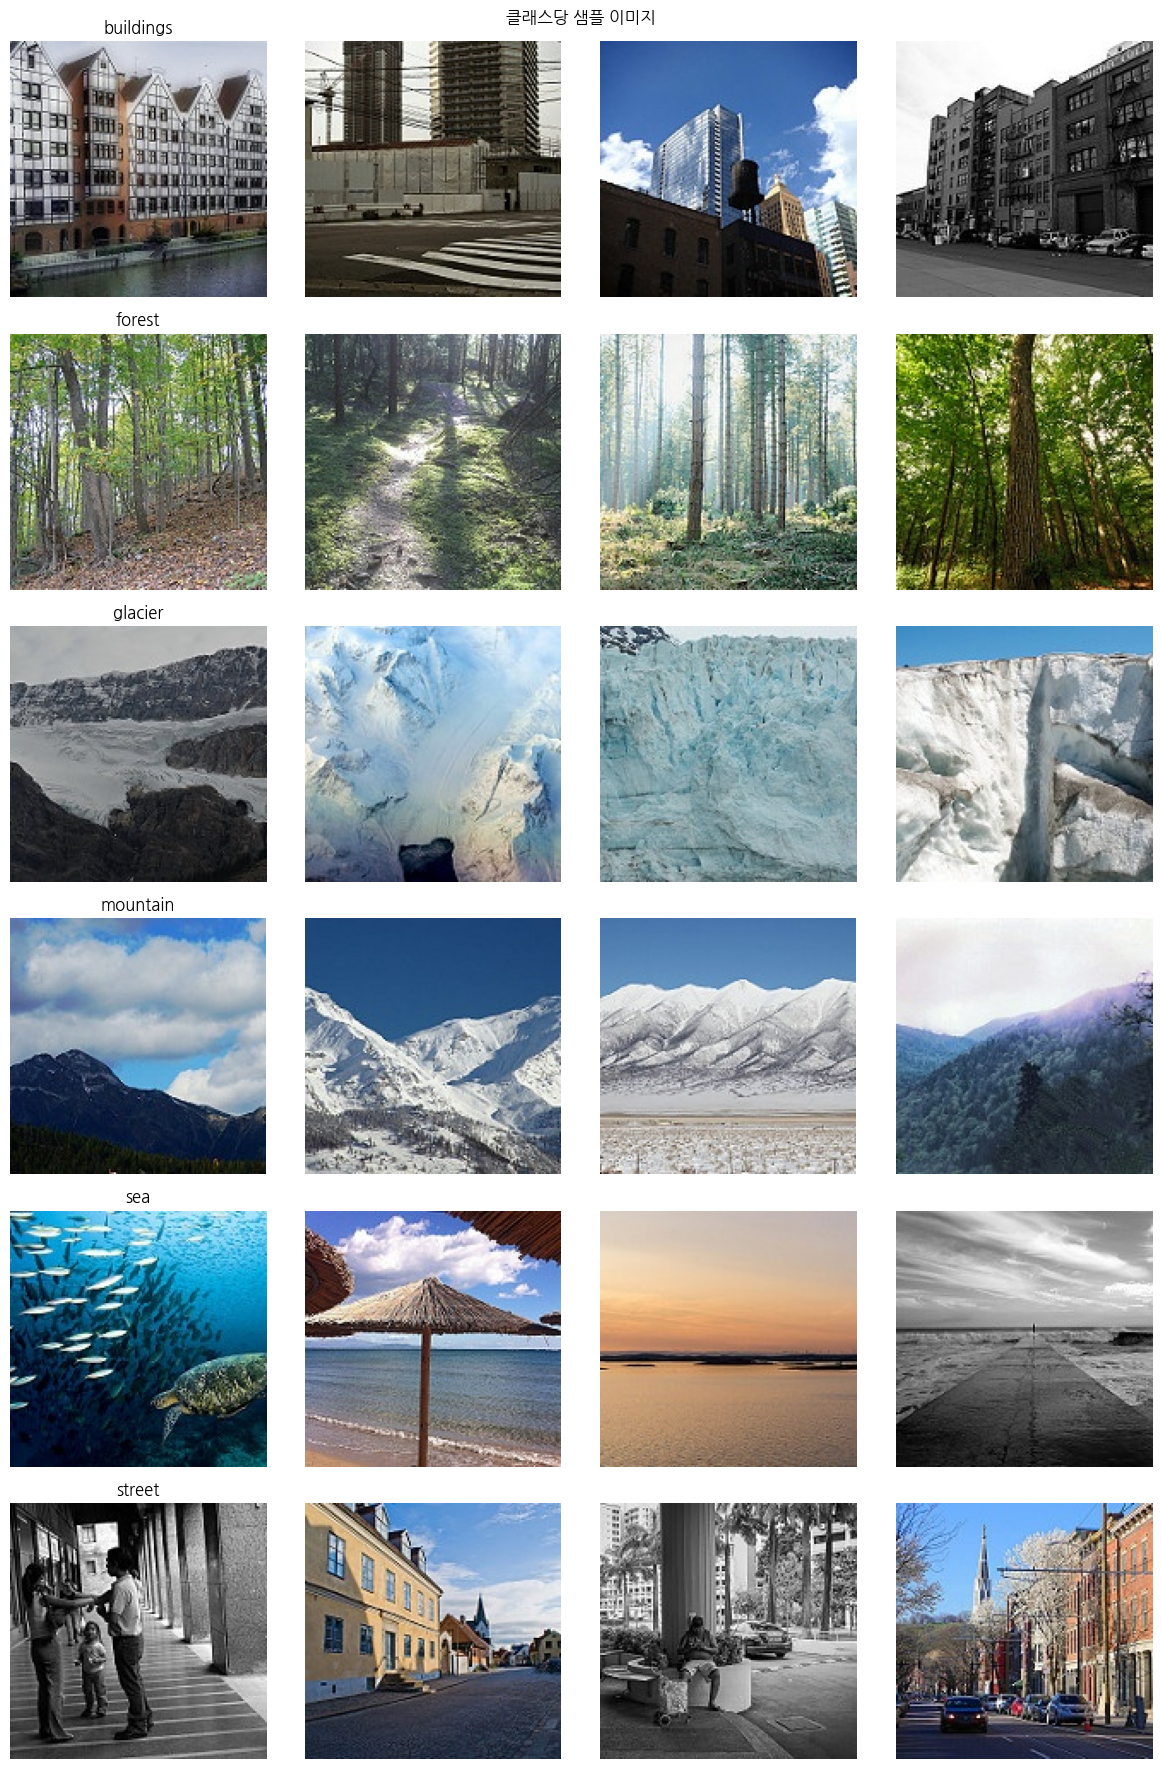

In [11]:
classes = sorted(os.listdir(TRAIN_DIR))
counts  = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes]

print('클래스별 이미지 수')
for c, n in zip(classes, counts):
    print(f'  {c:<12}: {n}')

plt.figure(figsize=(10, 4))
plt.bar(classes, counts)
plt.title('클래스별 이미지 수'); plt.tight_layout(); plt.show()

# 클래스당 4장씩 보기
from PIL import Image
fig, axes = plt.subplots(len(classes), 4, figsize=(12, 3*len(classes)))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs = random.sample(os.listdir(cls_dir), 4)
    for j, img_file in enumerate(imgs):
        img = Image.open(os.path.join(cls_dir, img_file))
        axes[i,j].imshow(img)
        axes[i,j].set_title(cls if j==0 else '')
        axes[i,j].axis('off')
plt.suptitle('클래스당 샘플 이미지'); plt.tight_layout(); plt.show()

**가설 적기**: 어떤 클래스끼리 헷갈릴 것 같나요? 한 줄 적어두세요.

> 예시: glacier와 mountain이 색감과 질감이 비슷해서 모델이 헷갈릴 것이다.

## [3] DataLoader 준비
속도가 느리면 numworkers=4로 늘리고 pinmemory=True 추가하여 봅니다.
## num_workers
- CPU 코어 수가 상한선. 캐글 T4는 보통 4코어라 4가 적당
- 너무 높으면 오히려 프로세스 생성 오버헤드로 느려짐
- 데이터셋이 작으면 num_workers=2 가 더 빠를 수도 있음
## pin_memory
- GPU 있을 때만 효과 있음. CPU only면 오히려 메모리 낭비
## batch_size
- 크면 GPU 메모리 한계에 걸림
- 캐글 T4 기준 64×64 이미지면 배치 128~256까지는 보통 괜찮음
- OOM 나면 절반으로 줄이면 됩니다

In [15]:
IMG_SIZE = 64
BATCH    = 256

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_full = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=transform)

# train / val 분할
n_val   = int(len(train_full) * 0.15)
n_train = len(train_full) - n_val
train_ds, val_ds = random_split(train_full, [n_train, n_val],
                                generator=torch.Generator().manual_seed(SEED))

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=4, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)

print(f'train {n_train} | val {n_val} | test {len(test_ds)}')
print(f'클래스: {train_full.classes}')

train 11929 | val 2105 | test 3000
클래스: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## [4] Simple CNN 모델 정의
Conv2d → BN → ReLU → MaxPool 블록 3개. 이게 베이스라인입니다.

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # 블록 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 블록 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 블록 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'총 파라미터 수: {total_params:,}')
print(model)

총 파라미터 수: 2,192,198
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)


## [5] 학습 함수 + v1 기본 학습

In [17]:
def train(model, train_dl, val_dl, epochs=30, lr=1e-3, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_acc, no_improve, best_state = 0, 0, None
    for epoch in range(1, epochs+1):
        # train
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            train_loss += loss.item()
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total   += len(labels)
        # val
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total   += len(labels)
        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        print(f'Epoch {epoch:2d} | loss {train_loss/len(train_dl):.4f} | '
              f'train_acc {train_acc:.4f} | val_acc {val_acc:.4f}')
        if val_acc > best_acc:
            best_acc, no_improve = val_acc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch}'); break
    model.load_state_dict(best_state)
    return model

model_v1 = SimpleCNN().to(device)
model_v1 = train(model_v1, train_dl, val_dl)

Epoch  1 | loss 1.1376 | train_acc 0.5538 | val_acc 0.6451
Epoch  2 | loss 0.7822 | train_acc 0.7082 | val_acc 0.7268
Epoch  3 | loss 0.6758 | train_acc 0.7491 | val_acc 0.7691
Epoch  4 | loss 0.6042 | train_acc 0.7802 | val_acc 0.7729
Epoch  5 | loss 0.5335 | train_acc 0.8066 | val_acc 0.7781
Epoch  6 | loss 0.4600 | train_acc 0.8339 | val_acc 0.7834
Epoch  7 | loss 0.4113 | train_acc 0.8546 | val_acc 0.8152
Epoch  8 | loss 0.3480 | train_acc 0.8765 | val_acc 0.8152
Epoch  9 | loss 0.2921 | train_acc 0.8990 | val_acc 0.7914
Epoch 10 | loss 0.2534 | train_acc 0.9085 | val_acc 0.8019
Epoch 11 | loss 0.1802 | train_acc 0.9412 | val_acc 0.7967
Epoch 12 | loss 0.1542 | train_acc 0.9462 | val_acc 0.8128
Early stop at epoch 12


## [6] 약점 분석 (오늘의 핵심)
**볼 것**: 가장 낮은 recall 클래스 / 혼동행렬에서 큰 숫자가 어느 칸에 있는가?

=== v1 Baseline ===

전체 정확도: 79.9%

              precision    recall  f1-score   support

   buildings       0.78      0.73      0.75       437
      forest       0.97      0.84      0.90       474
     glacier       0.76      0.78      0.77       553
    mountain       0.80      0.74      0.77       525
         sea       0.77      0.83      0.79       510
      street       0.76      0.88      0.81       501

    accuracy                           0.80      3000
   macro avg       0.81      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000



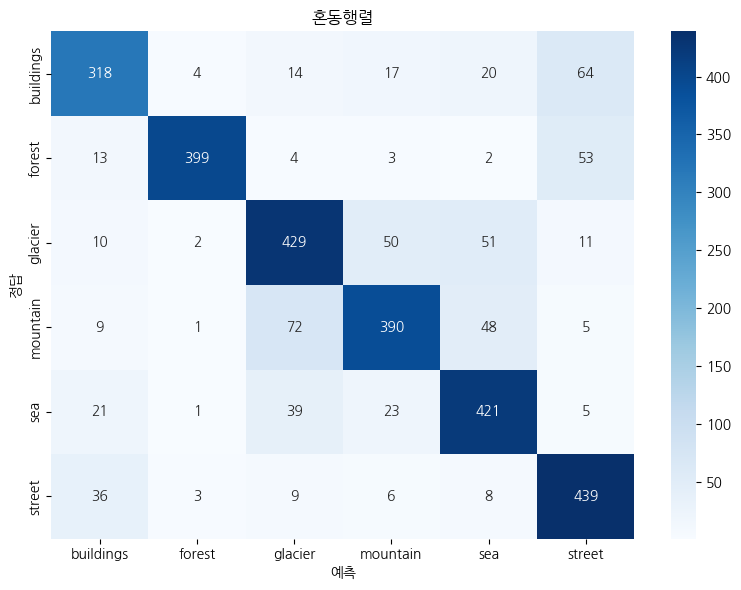

In [18]:
def evaluate(model, test_dl, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_dl:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    print(f'\n전체 정확도: {acc*100:.1f}%\n')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('혼동행렬'); plt.ylabel('정답'); plt.xlabel('예측')
    plt.tight_layout(); plt.show()
    return acc, all_preds, all_labels

print('=== v1 Baseline ===')
acc_v1, _, _ = evaluate(model_v1, test_dl, train_full.classes)

---
# 여기서부터 튜닝 실험

아래 셀들은 AI 프롬프트로 직접 채워넣으세요.
**한 번에 하나만 바꾸세요.** 두 개를 동시에 바꾸면 어느 게 효과 있었는지 알 수 없습니다.

## [7] v2 — Batch Normalization 추가

무엇을 바꿀지 정하고, AI에게 프롬프트를 붙여서 코드를 받아 실행하세요.

v2 파라미터 수: 2,192,646
Epoch  1 | loss 1.2300 | train_acc 0.5651 | val_acc 0.6570
Epoch  2 | loss 0.7293 | train_acc 0.7284 | val_acc 0.7439
Epoch  3 | loss 0.6004 | train_acc 0.7753 | val_acc 0.7644
Epoch  4 | loss 0.5235 | train_acc 0.8121 | val_acc 0.7663
Epoch  5 | loss 0.4564 | train_acc 0.8359 | val_acc 0.8200
Epoch  6 | loss 0.3919 | train_acc 0.8603 | val_acc 0.7829
Epoch  7 | loss 0.3725 | train_acc 0.8684 | val_acc 0.8100
Epoch  8 | loss 0.3307 | train_acc 0.8812 | val_acc 0.8252
Epoch  9 | loss 0.3010 | train_acc 0.8902 | val_acc 0.7914
Epoch 10 | loss 0.2738 | train_acc 0.9033 | val_acc 0.8314
Epoch 11 | loss 0.2181 | train_acc 0.9245 | val_acc 0.8238
Epoch 12 | loss 0.1985 | train_acc 0.9332 | val_acc 0.8252
Epoch 13 | loss 0.1624 | train_acc 0.9443 | val_acc 0.8352
Epoch 14 | loss 0.1271 | train_acc 0.9588 | val_acc 0.8228
Epoch 15 | loss 0.1235 | train_acc 0.9600 | val_acc 0.8209
Epoch 16 | loss 0.1035 | train_acc 0.9666 | val_acc 0.8375
Epoch 17 | loss 0.0797 | train_acc 

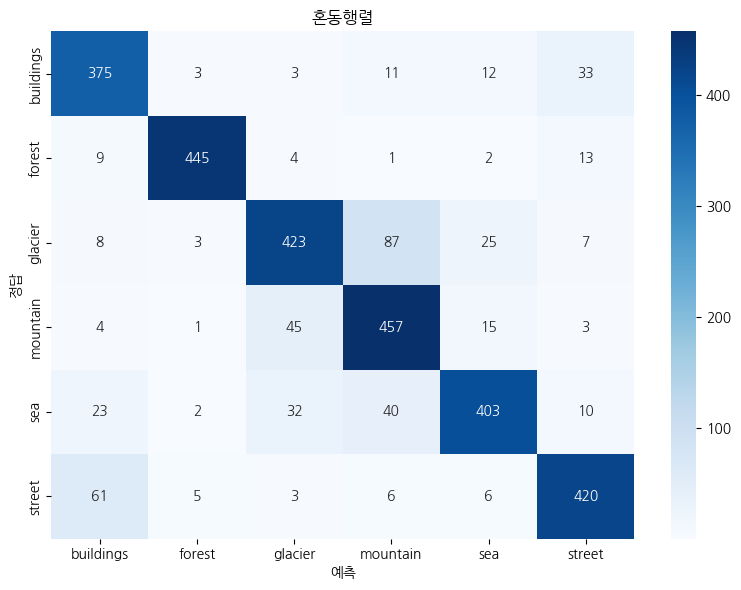

In [19]:
if 'tuning_results' not in globals():
    tuning_results = {'v1_baseline': acc_v1}

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

class CNNWithBN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_v2 = CNNWithBN().to(device)
print(f'v2 파라미터 수: {count_parameters(model_v2):,}')
model_v2 = train(model_v2, train_dl, val_dl)
print('=== v2 BatchNorm ===')
acc_v2, _, _ = evaluate(model_v2, test_dl, train_full.classes)
tuning_results['v2_batchnorm'] = acc_v2


## [8] v3 — Dropout 추가

v3 파라미터 수: 2,192,198
Epoch  1 | loss 1.1617 | train_acc 0.5472 | val_acc 0.6561
Epoch  2 | loss 0.8171 | train_acc 0.6960 | val_acc 0.6898
Epoch  3 | loss 0.7251 | train_acc 0.7326 | val_acc 0.7625
Epoch  4 | loss 0.6158 | train_acc 0.7721 | val_acc 0.7753
Epoch  5 | loss 0.5387 | train_acc 0.8038 | val_acc 0.7990
Epoch  6 | loss 0.4897 | train_acc 0.8194 | val_acc 0.8038
Epoch  7 | loss 0.4596 | train_acc 0.8354 | val_acc 0.8114
Epoch  8 | loss 0.3954 | train_acc 0.8574 | val_acc 0.8247
Epoch  9 | loss 0.3622 | train_acc 0.8676 | val_acc 0.8143
Epoch 10 | loss 0.3354 | train_acc 0.8759 | val_acc 0.8223
Epoch 11 | loss 0.3027 | train_acc 0.8893 | val_acc 0.8323
Epoch 12 | loss 0.2591 | train_acc 0.9069 | val_acc 0.8266
Epoch 13 | loss 0.2310 | train_acc 0.9168 | val_acc 0.8385
Epoch 14 | loss 0.2201 | train_acc 0.9201 | val_acc 0.8404
Epoch 15 | loss 0.1918 | train_acc 0.9323 | val_acc 0.8304
Epoch 16 | loss 0.1708 | train_acc 0.9390 | val_acc 0.8209
Epoch 17 | loss 0.1421 | train_acc 

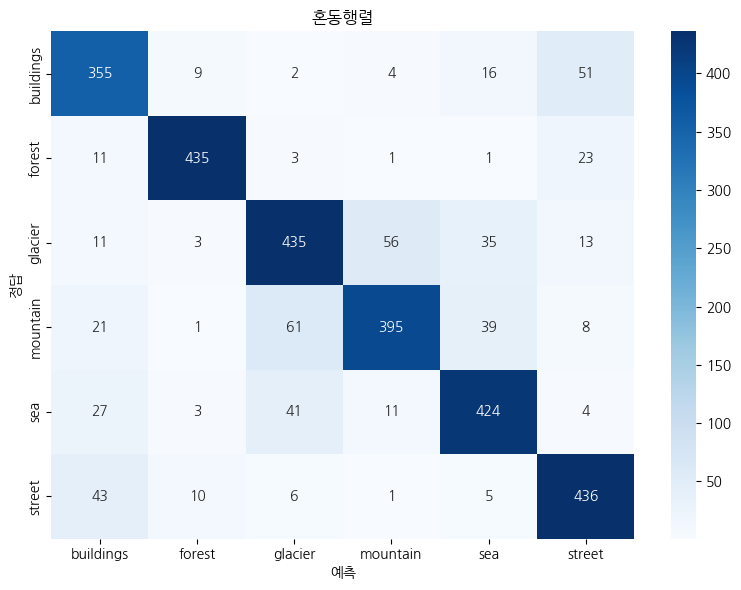

train 함수 로그의 train_acc와 val_acc 차이로 오버핏 여부를 확인하세요.


In [20]:
class CNNWithDropout(nn.Module):
    def __init__(self, num_classes=6, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_v3 = CNNWithDropout().to(device)
print(f'v3 파라미터 수: {count_parameters(model_v3):,}')
model_v3 = train(model_v3, train_dl, val_dl)
print('=== v3 Dropout ===')
acc_v3, _, _ = evaluate(model_v3, test_dl, train_full.classes)
tuning_results['v3_dropout'] = acc_v3
print('train 함수 로그의 train_acc와 val_acc 차이로 오버핏 여부를 확인하세요.')


## [9] v4 — 학습률 스케줄러 추가

Epoch  1 | lr 0.001000 | loss 1.1433 | train_acc 0.5545 | val_acc 0.6784
Epoch  2 | lr 0.001000 | loss 0.8052 | train_acc 0.7041 | val_acc 0.7230
Epoch  3 | lr 0.001000 | loss 0.6850 | train_acc 0.7499 | val_acc 0.7311
Epoch  4 | lr 0.001000 | loss 0.6125 | train_acc 0.7762 | val_acc 0.7720
Epoch  5 | lr 0.001000 | loss 0.5457 | train_acc 0.8026 | val_acc 0.7943
Epoch  6 | lr 0.001000 | loss 0.4938 | train_acc 0.8236 | val_acc 0.7919
Epoch  7 | lr 0.001000 | loss 0.4551 | train_acc 0.8370 | val_acc 0.8067
Epoch  8 | lr 0.001000 | loss 0.4129 | train_acc 0.8517 | val_acc 0.8019
Epoch  9 | lr 0.000500 | loss 0.3493 | train_acc 0.8727 | val_acc 0.8086
Epoch 10 | lr 0.000500 | loss 0.3113 | train_acc 0.8873 | val_acc 0.8285
Epoch 11 | lr 0.000500 | loss 0.2899 | train_acc 0.8963 | val_acc 0.8219
Epoch 12 | lr 0.000500 | loss 0.2715 | train_acc 0.9032 | val_acc 0.8124
Epoch 13 | lr 0.000500 | loss 0.2461 | train_acc 0.9126 | val_acc 0.8290
Epoch 14 | lr 0.000500 | loss 0.2256 | train_acc 0.

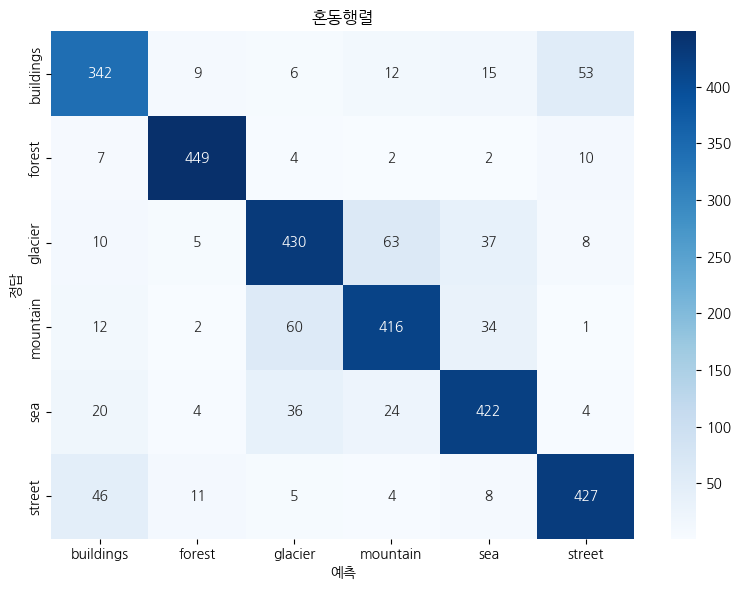

In [21]:
def train_with_scheduler(model, train_dl, val_dl, epochs=30, lr=1e-3, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

    best_acc, no_improve, best_state = 0, 0, None
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total += len(labels)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total += len(labels)

        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:2d} | lr {current_lr:.6f} | loss {train_loss/len(train_dl):.4f} | train_acc {train_acc:.4f} | val_acc {val_acc:.4f}')

        if val_acc > best_acc:
            best_acc, no_improve = val_acc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch}')
                break

        scheduler.step()

    model.load_state_dict(best_state)
    return model

model_v4 = CNNWithDropout().to(device)
model_v4 = train_with_scheduler(model_v4, train_dl, val_dl)
print('=== v4 StepLR + Dropout ===')
acc_v4, _, _ = evaluate(model_v4, test_dl, train_full.classes)
tuning_results['v4_scheduler'] = acc_v4


## V5 — 필터 수 늘리기

v5 파라미터 수: 4,566,918
Epoch  1 | loss 1.1288 | train_acc 0.5554 | val_acc 0.6390
Epoch  2 | loss 0.7696 | train_acc 0.7120 | val_acc 0.7382
Epoch  3 | loss 0.6331 | train_acc 0.7701 | val_acc 0.7796
Epoch  4 | loss 0.5347 | train_acc 0.8071 | val_acc 0.7905
Epoch  5 | loss 0.4657 | train_acc 0.8346 | val_acc 0.8038
Epoch  6 | loss 0.3877 | train_acc 0.8615 | val_acc 0.8019
Epoch  7 | loss 0.3253 | train_acc 0.8870 | val_acc 0.8219
Epoch  8 | loss 0.2637 | train_acc 0.9066 | val_acc 0.8119
Epoch  9 | loss 0.1835 | train_acc 0.9383 | val_acc 0.8143
Epoch 10 | loss 0.1343 | train_acc 0.9562 | val_acc 0.8057
Epoch 11 | loss 0.1155 | train_acc 0.9599 | val_acc 0.8166
Epoch 12 | loss 0.0668 | train_acc 0.9815 | val_acc 0.8185
Early stop at epoch 12
=== v5 Wider Filters ===

전체 정확도: 81.4%

              precision    recall  f1-score   support

   buildings       0.81      0.72      0.76       437
      forest       0.94      0.91      0.92       474
     glacier       0.78      0.80      0.79 

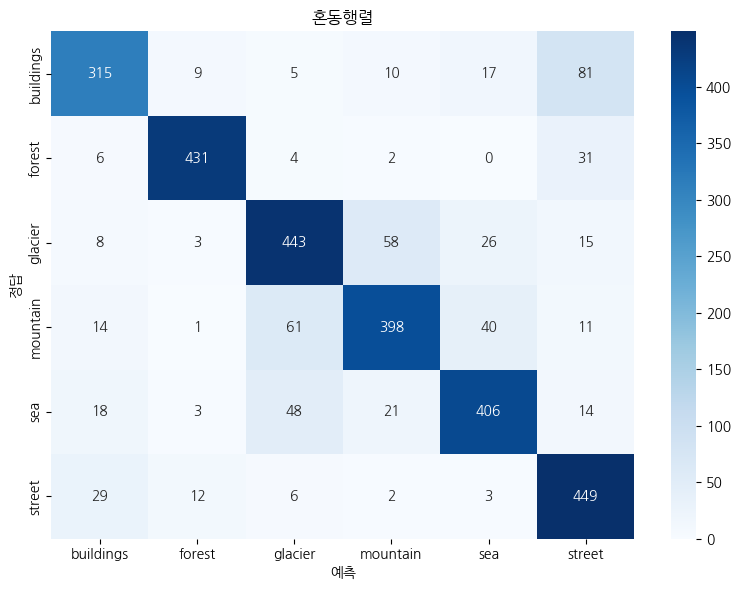

In [22]:
class WiderCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_v5 = WiderCNN().to(device)
print(f'v5 파라미터 수: {count_parameters(model_v5):,}')
model_v5 = train(model_v5, train_dl, val_dl)
print('=== v5 Wider Filters ===')
acc_v5, _, _ = evaluate(model_v5, test_dl, train_full.classes)
tuning_results['v5_wider'] = acc_v5


## V6 - 레이어 수 늘리기

v6 파라미터 수: 1,438,790
Epoch  1 | loss 1.2761 | train_acc 0.5013 | val_acc 0.6062
Epoch  2 | loss 0.9369 | train_acc 0.6337 | val_acc 0.6494
Epoch  3 | loss 0.7767 | train_acc 0.7063 | val_acc 0.7458
Epoch  4 | loss 0.6779 | train_acc 0.7494 | val_acc 0.7639
Epoch  5 | loss 0.5855 | train_acc 0.7856 | val_acc 0.7772
Epoch  6 | loss 0.5183 | train_acc 0.8125 | val_acc 0.8133
Epoch  7 | loss 0.4638 | train_acc 0.8327 | val_acc 0.8071
Epoch  8 | loss 0.4509 | train_acc 0.8397 | val_acc 0.8010
Epoch  9 | loss 0.3982 | train_acc 0.8567 | val_acc 0.8314
Epoch 10 | loss 0.3499 | train_acc 0.8763 | val_acc 0.8014
Epoch 11 | loss 0.3221 | train_acc 0.8853 | val_acc 0.8143
Epoch 12 | loss 0.2896 | train_acc 0.8987 | val_acc 0.8090
Epoch 13 | loss 0.2509 | train_acc 0.9099 | val_acc 0.8304
Epoch 14 | loss 0.1873 | train_acc 0.9345 | val_acc 0.8128
Early stop at epoch 14
=== v6 Deeper CNN ===

전체 정확도: 82.6%

              precision    recall  f1-score   support

   buildings       0.74      0.86    

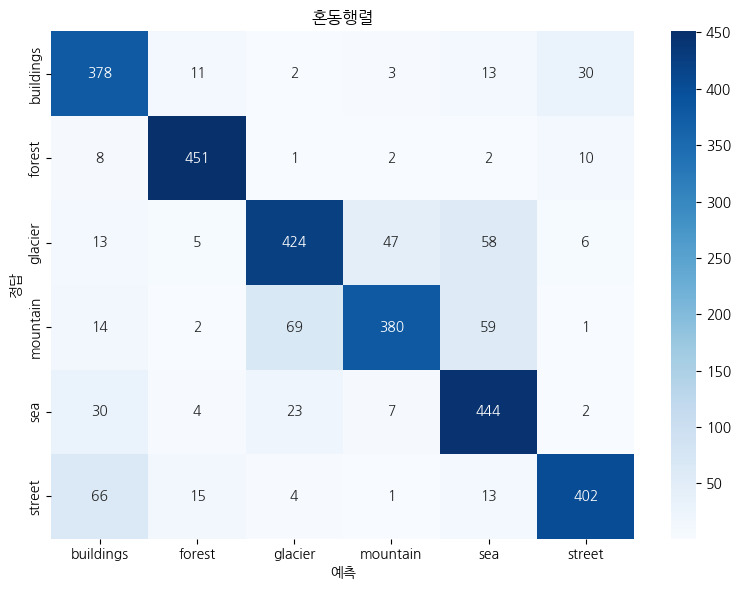

In [23]:
class DeeperCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_v6 = DeeperCNN().to(device)
print(f'v6 파라미터 수: {count_parameters(model_v6):,}')
model_v6 = train(model_v6, train_dl, val_dl)
print('=== v6 Deeper CNN ===')
acc_v6, _, _ = evaluate(model_v6, test_dl, train_full.classes)
tuning_results['v6_deeper'] = acc_v6


## V7 - 옵티마이저 바꾸기

Epoch  1 | loss 1.5178 | train_acc 0.4182 | val_acc 0.5268
Epoch  2 | loss 1.0976 | train_acc 0.5761 | val_acc 0.5910
Epoch  3 | loss 0.9464 | train_acc 0.6324 | val_acc 0.6048
Epoch  4 | loss 0.8666 | train_acc 0.6680 | val_acc 0.6304
Epoch  5 | loss 0.8200 | train_acc 0.6934 | val_acc 0.6917
Epoch  6 | loss 0.7483 | train_acc 0.7220 | val_acc 0.7107
Epoch  7 | loss 0.6910 | train_acc 0.7444 | val_acc 0.7449
Epoch  8 | loss 0.6578 | train_acc 0.7616 | val_acc 0.7601
Epoch  9 | loss 0.5977 | train_acc 0.7856 | val_acc 0.7292
Epoch 10 | loss 0.5670 | train_acc 0.7935 | val_acc 0.7729
Epoch 11 | loss 0.5450 | train_acc 0.8045 | val_acc 0.7824
Epoch 12 | loss 0.4846 | train_acc 0.8260 | val_acc 0.7800
Epoch 13 | loss 0.4493 | train_acc 0.8417 | val_acc 0.7990
Epoch 14 | loss 0.4184 | train_acc 0.8541 | val_acc 0.8086
Epoch 15 | loss 0.3995 | train_acc 0.8582 | val_acc 0.7610
Epoch 16 | loss 0.3650 | train_acc 0.8729 | val_acc 0.8024
Epoch 17 | loss 0.3120 | train_acc 0.8895 | val_acc 0.80

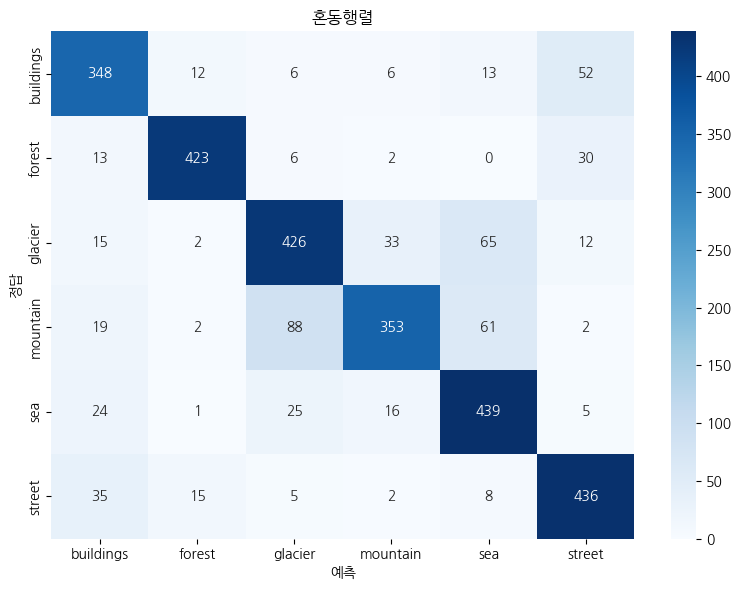

In [24]:
def train_sgd(model, train_dl, val_dl, epochs=30, lr=0.01, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

    best_acc, no_improve, best_state = 0, 0, None
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total += len(labels)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total += len(labels)

        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        print(f'Epoch {epoch:2d} | loss {train_loss/len(train_dl):.4f} | train_acc {train_acc:.4f} | val_acc {val_acc:.4f}')

        if val_acc > best_acc:
            best_acc, no_improve = val_acc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    return model

model_v7 = SimpleCNN().to(device)
model_v7 = train_sgd(model_v7, train_dl, val_dl, lr=0.01)
print('=== v7 SGD ===')
acc_v7, _, _ = evaluate(model_v7, test_dl, train_full.classes)
tuning_results['v7_sgd'] = acc_v7


## [10] 결과 비교 표

v1~v4 결과를 한 표로 정리하세요. AI에게 맡겨도 됩니다.

In [25]:
import pandas as pd

display_names = {
    'v1_baseline': 'v1 Baseline',
    'v2_batchnorm': 'v2 BatchNorm',
    'v3_dropout': 'v3 Dropout',
    'v4_scheduler': 'v4 StepLR + Dropout',
    'v5_wider': 'v5 Wider Filters',
    'v6_deeper': 'v6 Deeper CNN',
    'v7_sgd': 'v7 SGD',
}

result_df = pd.DataFrame([
    {'experiment': display_names[k], 'test_acc': v}
    for k, v in tuning_results.items()
]).sort_values('test_acc', ascending=False).reset_index(drop=True)

result_df['test_acc_pct'] = (result_df['test_acc'] * 100).round(2)
display(result_df)
print(f"best model: {result_df.loc[0, 'experiment']} ({result_df.loc[0, 'test_acc_pct']:.2f}%)")


,experiment,test_acc,test_acc_pct
0,v2 BatchNorm,0.841000,84.10
1,v4 StepLR + Dropout,0.828667,82.87
2,v3 Dropout,0.826667,82.67
3,v6 Deeper CNN,0.826333,82.63
4,v5 Wider Filters,0.814000,81.40
5,v7 SGD,0.808333,80.83
6,v1 Baseline,0.798667,79.87


best model: v2 BatchNorm (84.10%)
